In [1]:
!pip install yfinance --quiet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Download GBPJPY data
df = yf.download(
    tickers="GBPJPY=X",
    start="2000-01-01",
    end="2024-12-31",
    interval="1d"
)

# Reset and clean index
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Flatten MultiIndex columns if present
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

df.head()


/tmp/ipykernel_5023/300875257.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2003-12-01,187.630005,189.660004,187.740005,189.330002,0
2003-12-02,188.009995,188.809998,187.559998,187.669998,0
2003-12-03,187.089996,188.240005,186.490005,188.020004,0
2003-12-04,186.220001,187.029999,185.899994,187.029999,0
2003-12-05,185.880005,186.740005,185.830002,186.190002,0


In [3]:
# Extract Close price for analysis window
data = df["Close"].loc["2010-01-01":"2024-01-01"]

# Build DataFrame
plot_df = pd.DataFrame({
    "Close": data,
    "SMA20": data.rolling(20).mean(),
    "SMA50": data.rolling(50).mean()
})

# Golden Cross (Buy)
plot_df["Golden"] = (plot_df["SMA20"] > plot_df["SMA50"]) & \
                    (plot_df["SMA20"].shift(1) <= plot_df["SMA50"].shift(1))

# Death Cross (Sell)
plot_df["Death"] = (plot_df["SMA20"] < plot_df["SMA50"]) & \
                   (plot_df["SMA20"].shift(1) >= plot_df["SMA50"].shift(1))

# Signal column
plot_df["Signal"] = 0
plot_df.loc[plot_df["Golden"], "Signal"] = 1
plot_df.loc[plot_df["Death"],  "Signal"] = -1

plot_df.head()


,Close,SMA20,SMA50,Golden,Death,Signal
Date,,,,,,
2010-01-01,150.240005,NaN,NaN,False,False,0
2010-01-04,148.990005,NaN,NaN,False,False,0
2010-01-05,146.380005,NaN,NaN,False,False,0
2010-01-06,147.929993,NaN,NaN,False,False,0
2010-01-07,148.779999,NaN,NaN,False,False,0


In [4]:
# Compute ATR(14)
high = df["High"].loc[plot_df.index]
low = df["Low"].loc[plot_df.index]
close = df["Close"].loc[plot_df.index]

tr = pd.concat([
    high - low,
    (high - close.shift(1)).abs(),
    (low - close.shift(1)).abs()
], axis=1).max(axis=1)

atr = tr.rolling(14).mean()
plot_df["ATR"] = atr

# Parameters
SL_mult = 2
TP_mult = 3

# Trade simulation
trades = []
position = 0
entry_price = None
entry_date = None
sl = None
tp = None

for date, row in plot_df.iterrows():
    price = row["Close"]
    signal = row["Signal"]
    atr_val = row["ATR"]

    # Entry
    if position == 0 and signal == 1:
        position = 1
        entry_price = price
        entry_date = date
        sl = entry_price - SL_mult * atr_val
        tp = entry_price + TP_mult * atr_val

    # Exit logic
    elif position == 1:
        exit_reason = None

        if price <= sl:
            exit_reason = "Stop-Loss"
        elif price >= tp:
            exit_reason = "Take-Profit"
        elif signal == -1:
            exit_reason = "Crossover"

        if exit_reason:
            ret = (price / entry_price) - 1
            holding = (date - entry_date).days

            trades.append({
                "Entry Date": entry_date,
                "Exit Date": date,
                "Entry Price": entry_price,
                "Exit Price": price,
                "Return": ret,
                "Holding Days": holding,
                "Exit Reason": exit_reason
            })

            position = 0

trade_df = pd.DataFrame(trades)
trade_df.head()


,Entry Date,Exit Date,Entry Price,Exit Price,Return,Holding Days,Exit Reason
0,2010-04-08,2010-05-06,142.751999,135.000000,-0.054304,28,Stop-Loss
1,2010-07-13,2010-08-25,134.792007,129.653000,-0.038125,43,Stop-Loss
2,2010-10-13,2010-10-15,129.289993,130.395004,0.008547,2,Crossover
3,2010-11-23,2010-12-23,132.774994,128.699997,-0.030691,30,Stop-Loss
4,2011-01-31,2011-02-16,129.903000,135.061005,0.039707,16,Take-Profit


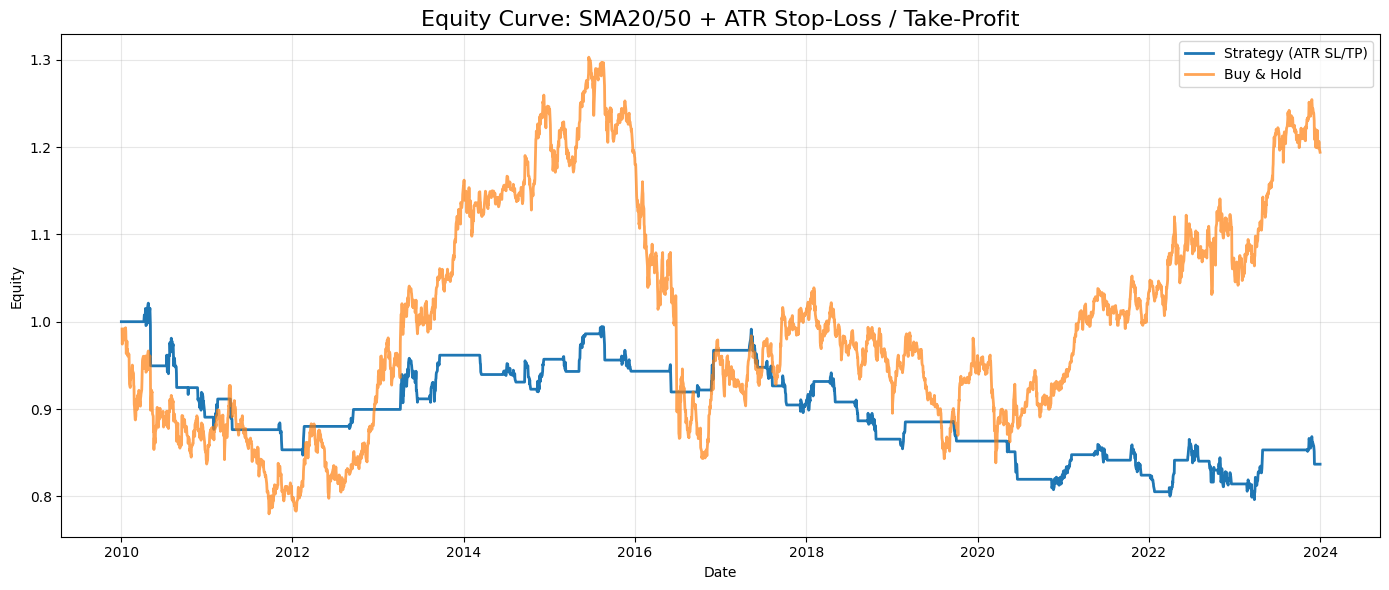

In [5]:
# Daily returns
plot_df["Return"] = plot_df["Close"].pct_change()

# Strategy returns
plot_df["Strategy_Return"] = 0.0
for _, t in trade_df.iterrows():
    start = t["Entry Date"]
    end   = t["Exit Date"]
    plot_df.loc[start:end, "Strategy_Return"] = plot_df["Return"].loc[start:end]

# Equity curves
plot_df["Equity"] = (1 + plot_df["Strategy_Return"]).cumprod()
plot_df["BuyHold"] = (1 + plot_df["Return"]).cumprod()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(plot_df["Equity"], label="Strategy (ATR SL/TP)", linewidth=2)
plt.plot(plot_df["BuyHold"], label="Buy & Hold", linewidth=2, alpha=0.7)
plt.title("Equity Curve: SMA20/50 + ATR Stop-Loss / Take-Profit", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
# Total return
total_return = plot_df["Equity"].iloc[-1] - 1
bh_return = plot_df["BuyHold"].iloc[-1] - 1

# Years in sample
years = (plot_df.index[-1] - plot_df.index[0]).days / 365

# CAGR
cagr = (plot_df["Equity"].iloc[-1])**(1/years) - 1
bh_cagr = (plot_df["BuyHold"].iloc[-1])**(1/years) - 1

# Volatility (annualized)
vol = plot_df["Strategy_Return"].std() * np.sqrt(252)
bh_vol = plot_df["Return"].std() * np.sqrt(252)

# Sharpe ratios
sharpe = cagr / vol if vol != 0 else 0
bh_sharpe = bh_cagr / bh_vol if bh_vol != 0 else 0

# Summary table
summary = pd.DataFrame({
    "Metric": [
        "Total Return", "Buy & Hold Return",
        "CAGR", "Buy & Hold CAGR",
        "Volatility", "Buy & Hold Volatility",
        "Sharpe Ratio", "Buy & Hold Sharpe"
    ],
    "Value": [
        f"{total_return:.2%}", f"{bh_return:.2%}",
        f"{cagr:.2%}", f"{bh_cagr:.2%}",
        f"{vol:.2%}", f"{bh_vol:.2%}",
        f"{sharpe:.2f}", f"{bh_sharpe:.2f}"
    ]
})

summary


,Metric,Value
0,Total Return,-16.32%
1,Buy & Hold Return,19.40%
2,CAGR,-1.26%
3,Buy & Hold CAGR,1.27%
4,Volatility,5.06%
5,Buy & Hold Volatility,11.40%
6,Sharpe Ratio,-0.25
7,Buy & Hold Sharpe,0.11


In [7]:
# Ensure Equity exists
if "Equity" not in plot_df.columns:
    plot_df["Equity"] = (1 + plot_df["Strategy_Return"]).cumprod()

# Drawdown
plot_df["Peak"] = plot_df["Equity"].cummax()
plot_df["Drawdown"] = plot_df["Equity"] / plot_df["Peak"] - 1
max_dd = plot_df["Drawdown"].min()

# Trade statistics
num_trades = len(trade_df)
wins = (trade_df["Return"] > 0).sum()
losses = (trade_df["Return"] < 0).sum()
win_rate = wins / num_trades if num_trades > 0 else 0
avg_ret = trade_df["Return"].mean()
best_trade = trade_df["Return"].max()
worst_trade = trade_df["Return"].min()
avg_hold = trade_df["Holding Days"].mean()

# Summary table
stats = pd.DataFrame({
    "Metric": [
        "Max Drawdown",
        "Number of Trades",
        "Win Rate",
        "Average Return",
        "Best Trade",
        "Worst Trade",
        "Avg Holding Days"
    ],
    "Value": [
        f"{max_dd:.2%}",
        num_trades,
        f"{win_rate:.2%}",
        f"{avg_ret:.2%}",
        f"{best_trade:.2%}",
        f"{worst_trade:.2%}",
        f"{avg_hold:.1f}"
    ]
})

stats


,Metric,Value
0,Max Drawdown,-22.03%
1,Number of Trades,46
2,Win Rate,32.61%
3,Average Return,-0.48%
4,Best Trade,5.36%
5,Worst Trade,-5.43%
6,Avg Holding Days,26.0


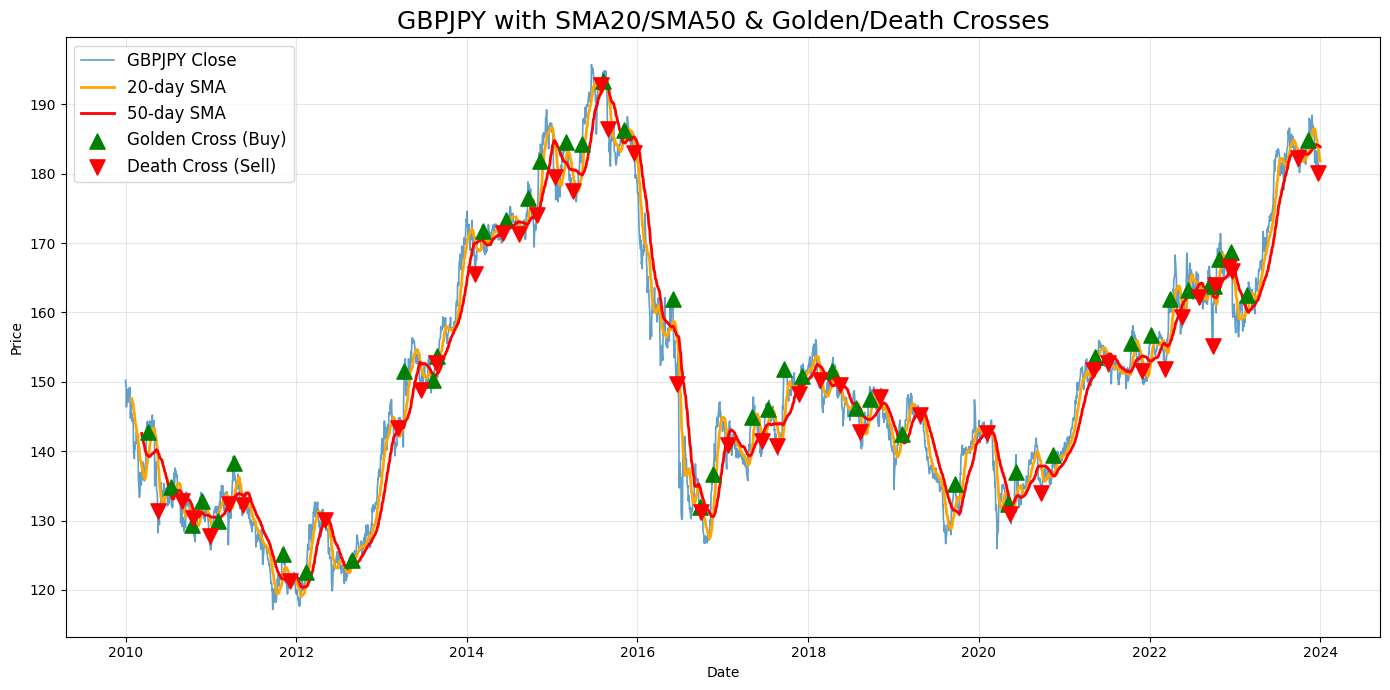

In [8]:
plt.figure(figsize=(14, 7))

plt.plot(plot_df.index, plot_df["Close"], label="GBPJPY Close", linewidth=1.2, alpha=0.7)
plt.plot(plot_df.index, plot_df["SMA20"], label="20-day SMA", color="orange", linewidth=2)
plt.plot(plot_df.index, plot_df["SMA50"], label="50-day SMA", color="red", linewidth=2)

plt.scatter(plot_df.index[plot_df["Golden"]], plot_df["Close"][plot_df["Golden"]],
            color="green", marker="^", s=120, label="Golden Cross (Buy)", zorder=5)

plt.scatter(plot_df.index[plot_df["Death"]], plot_df["Close"][plot_df["Death"]],
            color="red", marker="v", s=120, label="Death Cross (Sell)", zorder=5)

plt.title("GBPJPY with SMA20/SMA50 & Golden/Death Crosses", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [9]:
df.to_csv("gbpjpy_data.csv")


In [10]:
from google.colab import files
files.download("gbpjpy_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>